In [1]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import pickle

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("ecommerce_customer_churn.csv")

In [3]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width", None)

In [4]:
df.head()


,CustomerID,Gender,Age,CityTier,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,Membership,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
0,CUST100000,Male,68,2,0,Mobile Phone,37,Credit Card,3.4,2,Laptop & Accessories,3,Single,6,1,2,12,7,3,180.83,12297.59,5.3,Bronze,96,12,14,1
1,CUST100001,Female,57,1,5,Mobile Phone,31,UPI,3.2,5,Grocery,1,Married,2,1,4,19,41,38,243.98,4257.89,22.4,Bronze,89,3,14,1
2,CUST100002,Female,24,1,20,Mobile Phone,49,Debit Card,3.8,6,Laptop & Accessories,1,Single,6,0,21,12,7,10,22.65,9325.14,59.6,Gold,0,20,9,1
3,CUST100003,Female,49,3,45,Tablet,6,UPI,4.7,1,Fashion,1,Single,2,1,0,19,15,0,77.40,13375.94,39.1,Platinum,59,19,14,0
4,CUST100004,Male,65,1,4,Mobile Phone,19,UPI,4.3,6,Fashion,2,Married,7,0,14,4,30,51,323.41,8671.20,10.5,Bronze,1,18,14,1


In [5]:
df.tail()


,CustomerID,Gender,Age,CityTier,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,Membership,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
4995,CUST104995,Female,21,3,7,Computer,5,Credit Card,4.7,4,Mobile,3,Single,3,1,8,16,23,6,225.79,18127.08,50.1,Silver,19,15,3,0
4996,CUST104996,Male,66,2,9,Mobile Phone,17,Credit Card,2.6,6,Electronics,1,Divorced,3,1,20,22,33,1,313.96,12499.84,38.0,Platinum,87,15,14,1
4997,CUST104997,Male,30,1,13,Mobile Phone,10,UPI,2.5,3,Laptop & Accessories,1,Single,8,1,21,25,25,20,179.63,4771.58,41.7,Bronze,57,19,0,1
4998,CUST104998,Female,53,3,9,Mobile Phone,26,UPI,2.1,1,Laptop & Accessories,1,Single,4,0,6,13,14,18,260.66,15991.82,8.5,Bronze,88,0,7,0
4999,CUST104999,Female,52,1,10,Mobile Phone,21,Debit Card,4.3,4,Fashion,3,Married,1,0,6,15,35,5,70.53,18196.23,47.9,Bronze,18,13,8,0


In [6]:
df.shape


(5000, 27)

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'CityTier', 'Tenure',
       'PreferredLoginDevice', 'WarehouseToHome', 'PreferredPaymentMode',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat',
       'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromLastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'AverageOrderValue',
       'ReturnRate', 'Membership', 'DiscountUsage', 'CustomerSupportCalls',
       'DeliveryDelay', 'Churn'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5000 non-null   object 
 1   Gender                       5000 non-null   object 
 2   Age                          5000 non-null   int64  
 3   CityTier                     5000 non-null   int64  
 4   Tenure                       5000 non-null   int64  
 5   PreferredLoginDevice         5000 non-null   object 
 6   WarehouseToHome              5000 non-null   int64  
 7   PreferredPaymentMode         5000 non-null   object 
 8   HourSpendOnApp               5000 non-null   float64
 9   NumberOfDeviceRegistered     5000 non-null   int64  
 10  PreferedOrderCat             5000 non-null   object 
 11  SatisfactionScore            5000 non-null   int64  
 12  MaritalStatus                5000 non-null   object 
 13  NumberOfAddress   

In [9]:
df.describe()


,Age,CityTier,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.629600,1.796600,13.144400,27.812600,2.468000,3.527600,3.009200,4.51100,0.319800,14.94960,12.677800,25.574800,17.397800,249.825764,10087.395664,30.01100,50.393800,10.015200,7.465400,0.241600
std,15.173123,0.809543,13.078905,13.214962,1.446636,1.719136,1.424613,2.29341,0.466446,9.04521,7.538472,14.471997,17.719942,145.284567,5671.583454,17.21999,29.254878,6.070547,4.631835,0.428096
min,18.000000,1.000000,0.000000,5.000000,0.000000,1.000000,1.000000,1.00000,0.000000,0.00000,0.000000,1.000000,0.000000,0.090000,205.540000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.000000,4.000000,16.000000,1.200000,2.000000,2.000000,2.00000,0.000000,7.00000,6.000000,13.000000,5.000000,123.875000,5266.845000,14.97500,25.000000,5.000000,3.000000,0.000000
50%,43.000000,2.000000,9.000000,28.000000,2.500000,4.000000,3.000000,5.00000,0.000000,15.00000,13.000000,26.000000,12.000000,246.635000,10021.835000,30.30000,50.000000,10.000000,7.000000,0.000000
75%,57.000000,2.000000,18.000000,39.000000,3.700000,5.000000,4.000000,6.00000,1.000000,23.00000,19.000000,38.000000,25.000000,376.900000,14946.890000,44.70000,76.000000,15.000000,11.000000,0.000000
max,70.000000,3.000000,60.000000,50.000000,5.000000,6.000000,5.000000,8.00000,1.000000,30.00000,25.000000,50.000000,90.000000,499.930000,19994.130000,60.00000,100.000000,20.000000,15.000000,1.000000


In [10]:
df.dtypes


CustomerID                      object
Gender                          object
Age                              int64
CityTier                         int64
Tenure                           int64
PreferredLoginDevice            object
WarehouseToHome                  int64
PreferredPaymentMode            object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromLastYear      int64
CouponUsed                       int64
OrderCount                       int64
DaySinceLastOrder                int64
CashbackAmount                 float64
AverageOrderValue              float64
ReturnRate                     float64
Membership                      object
DiscountUsage                    int64
CustomerSupportCalls             int64
DeliveryDelay            

In [11]:
df.describe(include="all")


,CustomerID,Gender,Age,CityTier,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,Membership,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
count,5000,5000,5000.000000,5000.000000,5000.000000,5000,5000.000000,5000,5000.000000,5000.000000,5000,5000.000000,5000,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000,5000.000000,5000.000000,5000.000000,5000.000000
unique,5000,2,NaN,NaN,NaN,3,NaN,5,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN
top,CUST100000,Male,NaN,NaN,NaN,Mobile Phone,NaN,UPI,NaN,NaN,Electronics,NaN,Single,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bronze,NaN,NaN,NaN,NaN
freq,1,2748,NaN,NaN,NaN,3004,NaN,1429,NaN,NaN,1003,NaN,2216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1990,NaN,NaN,NaN,NaN
mean,NaN,NaN,43.629600,1.796600,13.144400,NaN,27.812600,NaN,2.468000,3.527600,NaN,3.009200,NaN,4.51100,0.319800,14.94960,12.677800,25.574800,17.397800,249.825764,10087.395664,30.01100,NaN,50.393800,10.015200,7.465400,0.241600
std,NaN,NaN,15.173123,0.809543,13.078905,NaN,13.214962,NaN,1.446636,1.719136,NaN,1.424613,NaN,2.29341,0.466446,9.04521,7.538472,14.471997,17.719942,145.284567,5671.583454,17.21999,NaN,29.254878,6.070547,4.631835,0.428096
min,NaN,NaN,18.000000,1.000000,0.000000,NaN,5.000000,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.00000,0.000000,0.00000,0.000000,1.000000,0.000000,0.090000,205.540000,0.00000,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,30.000000,1.000000,4.000000,NaN,16.000000,NaN,1.200000,2.000000,NaN,2.000000,NaN,2.00000,0.000000,7.00000,6.000000,13.000000,5.000000,123.875000,5266.845000,14.97500,NaN,25.000000,5.000000,3.000000,0.000000
50%,NaN,NaN,43.000000,2.000000,9.000000,NaN,28.000000,NaN,2.500000,4.000000,NaN,3.000000,NaN,5.00000,0.000000,15.00000,13.000000,26.000000,12.000000,246.635000,10021.835000,30.30000,NaN,50.000000,10.000000,7.000000,0.000000
75%,NaN,NaN,57.000000,2.000000,18.000000,NaN,39.000000,NaN,3.700000,5.000000,NaN,4.000000,NaN,6.00000,1.000000,23.00000,19.000000,38.000000,25.000000,376.900000,14946.890000,44.70000,NaN,76.000000,15.000000,11.000000,0.000000


In [12]:
df.head()


,CustomerID,Gender,Age,CityTier,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,Membership,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
0,CUST100000,Male,68,2,0,Mobile Phone,37,Credit Card,3.4,2,Laptop & Accessories,3,Single,6,1,2,12,7,3,180.83,12297.59,5.3,Bronze,96,12,14,1
1,CUST100001,Female,57,1,5,Mobile Phone,31,UPI,3.2,5,Grocery,1,Married,2,1,4,19,41,38,243.98,4257.89,22.4,Bronze,89,3,14,1
2,CUST100002,Female,24,1,20,Mobile Phone,49,Debit Card,3.8,6,Laptop & Accessories,1,Single,6,0,21,12,7,10,22.65,9325.14,59.6,Gold,0,20,9,1
3,CUST100003,Female,49,3,45,Tablet,6,UPI,4.7,1,Fashion,1,Single,2,1,0,19,15,0,77.40,13375.94,39.1,Platinum,59,19,14,0
4,CUST100004,Male,65,1,4,Mobile Phone,19,UPI,4.3,6,Fashion,2,Married,7,0,14,4,30,51,323.41,8671.20,10.5,Bronze,1,18,14,1


In [13]:
df.isnull().sum()


CustomerID                     0
Gender                         0
Age                            0
CityTier                       0
Tenure                         0
PreferredLoginDevice           0
WarehouseToHome                0
PreferredPaymentMode           0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromLastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
AverageOrderValue              0
ReturnRate                     0
Membership                     0
DiscountUsage                  0
CustomerSupportCalls           0
DeliveryDelay                  0
Churn                          0
dtype: int64

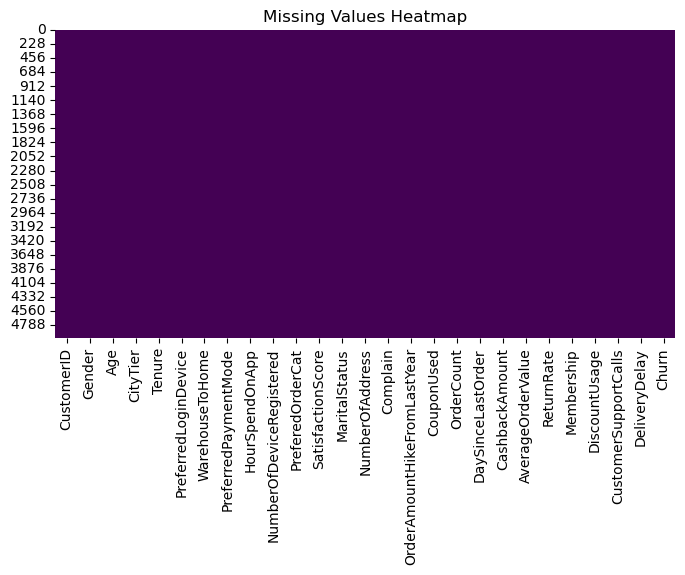

In [14]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [15]:
df.duplicated().sum()


np.int64(0)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df["Churn"].value_counts()

Churn
0    3792
1    1208
Name: count, dtype: int64

In [18]:
df["Churn"].value_counts(normalize=True)*100

Churn
0    75.84
1    24.16
Name: proportion, dtype: float64

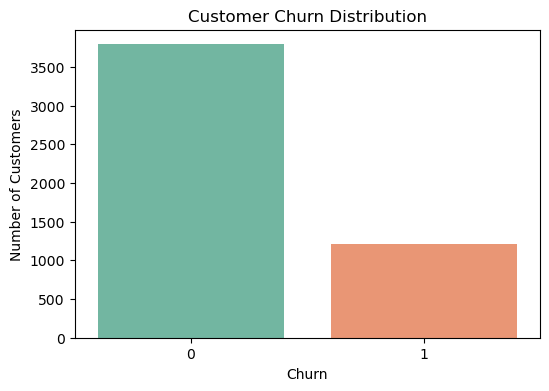

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df,
    palette="Set2"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns

categorical_columns = df.select_dtypes(include="object").columns

print("Numerical Columns")
print(numerical_columns)

print()

print("Categorical Columns")
print(categorical_columns)

Numerical Columns
Index(['Age', 'CityTier', 'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
       'Complain', 'OrderAmountHikeFromLastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'AverageOrderValue',
       'ReturnRate', 'DiscountUsage', 'CustomerSupportCalls', 'DeliveryDelay',
       'Churn'],
      dtype='object')

Categorical Columns
Index(['CustomerID', 'Gender', 'PreferredLoginDevice', 'PreferredPaymentMode',
       'PreferedOrderCat', 'MaritalStatus', 'Membership'],
      dtype='object')


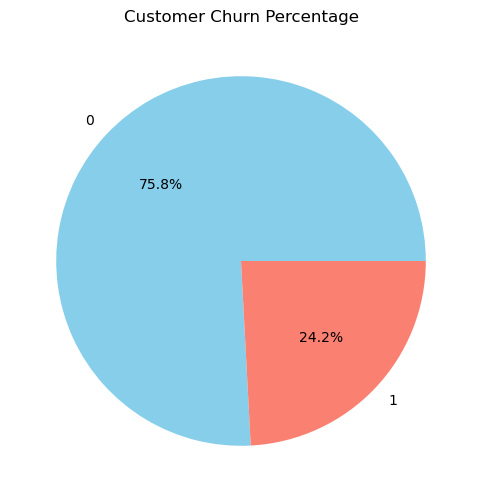

In [22]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","salmon"]
)

plt.ylabel("")
plt.title("Customer Churn Percentage")

plt.show()

In [23]:
df.rename(
    columns={"PreferedOrderCat": "PreferredOrderCategory"},
    inplace=True
)

In [24]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'CityTier', 'Tenure',
       'PreferredLoginDevice', 'WarehouseToHome', 'PreferredPaymentMode',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferredOrderCategory',
       'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromLastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount', 'AverageOrderValue',
       'ReturnRate', 'Membership', 'DiscountUsage', 'CustomerSupportCalls',
       'DeliveryDelay', 'Churn'],
      dtype='object')

In [25]:
df.drop("CustomerID", axis=1, inplace=True)

In [26]:
df.head()

,Gender,Age,CityTier,Tenure,PreferredLoginDevice,WarehouseToHome,PreferredPaymentMode,HourSpendOnApp,NumberOfDeviceRegistered,PreferredOrderCategory,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromLastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,AverageOrderValue,ReturnRate,Membership,DiscountUsage,CustomerSupportCalls,DeliveryDelay,Churn
0,Male,68,2,0,Mobile Phone,37,Credit Card,3.4,2,Laptop & Accessories,3,Single,6,1,2,12,7,3,180.83,12297.59,5.3,Bronze,96,12,14,1
1,Female,57,1,5,Mobile Phone,31,UPI,3.2,5,Grocery,1,Married,2,1,4,19,41,38,243.98,4257.89,22.4,Bronze,89,3,14,1
2,Female,24,1,20,Mobile Phone,49,Debit Card,3.8,6,Laptop & Accessories,1,Single,6,0,21,12,7,10,22.65,9325.14,59.6,Gold,0,20,9,1
3,Female,49,3,45,Tablet,6,UPI,4.7,1,Fashion,1,Single,2,1,0,19,15,0,77.40,13375.94,39.1,Platinum,59,19,14,0
4,Male,65,1,4,Mobile Phone,19,UPI,4.3,6,Fashion,2,Married,7,0,14,4,30,51,323.41,8671.20,10.5,Bronze,1,18,14,1


In [27]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [28]:
print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5000, 25)
Target Shape : (5000,)


In [29]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Gender', 'PreferredLoginDevice', 'PreferredPaymentMode',
       'PreferredOrderCategory', 'MaritalStatus', 'Membership'],
      dtype='object')


In [30]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [31]:
X.shape

(5000, 36)

In [32]:
y.unique()

array([1, 0])

In [33]:
print("Features :", X.shape)
print("Target :", y.shape)

Features : (5000, 36)
Target : (5000,)


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (4000, 36)
Testing Features  : (1000, 36)
Training Target   : (4000,)
Testing Target    : (1000,)


In [45]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [46]:
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
y_pred = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 78.40%


In [49]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[751  16]
 [200  33]]


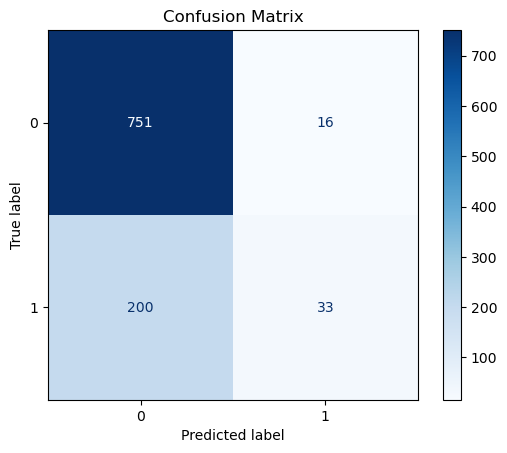

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.98      0.87       767
           1       0.67      0.14      0.23       233

    accuracy                           0.78      1000
   macro avg       0.73      0.56      0.55      1000
weighted avg       0.76      0.78      0.73      1000



In [52]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,SatisfactionScore,0.074610
8,Complain,0.068000
15,ReturnRate,0.059399
2,Tenure,0.058673
13,CashbackAmount,0.058568
14,AverageOrderValue,0.054987
17,CustomerSupportCalls,0.054422
11,OrderCount,0.051687
16,DiscountUsage,0.047305
12,DaySinceLastOrder,0.047293


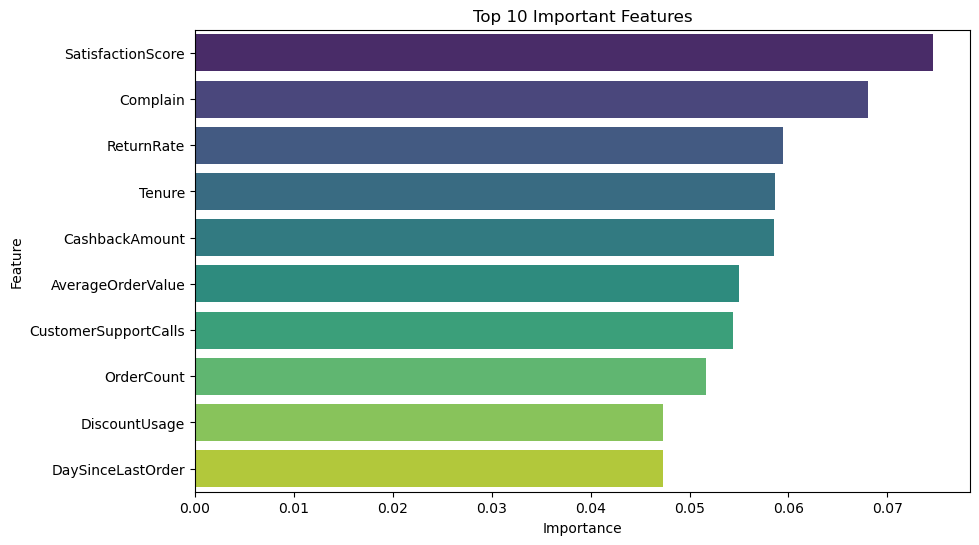

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [54]:
pickle.dump(model, open("ecommerce_churn_model.pkl", "wb"))

In [55]:
pickle.dump(X.columns, open("feature_names.pkl", "wb"))